# AMR Project - Step 5: SHAP Explanations (NCBI Dataset)

This notebook covers model interpretability using SHAP on our new trained XGBoost classifier.

### Objectives:
1. **SHAP Tree Explainer**: Compute SHAP values on a sample of 500 records from the test set.
2. **Global Interpretability**: Plot a beeswarm feature importance plot.
3. **Local Explanations**: Generate individual waterfall plots for predicted Resistant and Susceptible cases.

In [1]:
import os
import pickle
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import xgboost as xgbz
import shap

## 1. Load Data and Sanitize Column Names

In [2]:
preprocessed_path = "../data/processed/preprocessed_data.csv"
df = pd.read_csv(preprocessed_path, low_memory=False)

X = df.drop(columns=['Target'])
y = df['Target']

def sanitize_column_names(columns):
    seen = {}
    sanitized = []
    for col in columns:
        clean_col = re.sub(r'[^a-zA-Z0-9]', '_', str(col))
        clean_col = re.sub(r'_+', '_', clean_col).strip('_')
        if clean_col in seen:
            seen[clean_col] += 1
            clean_col = f"{clean_col}_{seen[clean_col]}"
        else:
            seen[clean_col] = 0
        sanitized.append(clean_col)
    return sanitized

X.columns = sanitize_column_names(X.columns)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

## 2. Load the XGBoost Model

In [3]:
xgb_path = "../models/xgb_model_new.pkl"
with open(xgb_path, 'rb') as f:
    model = pickle.load(f)

## 3. Compute SHAP Values

In [4]:
np.random.seed(42)
sample_size = 500
sample_indices = np.random.choice(X_test.index, size=sample_size, replace=False)
X_sample = X_test.loc[sample_indices]

print("Initializing TreeExplainer and calculating SHAP values...")
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_sample)
print("SHAP values calculated.")

Initializing TreeExplainer and calculating SHAP values...
SHAP values calculated.


## 4. Global Feature Importance Summary Plot

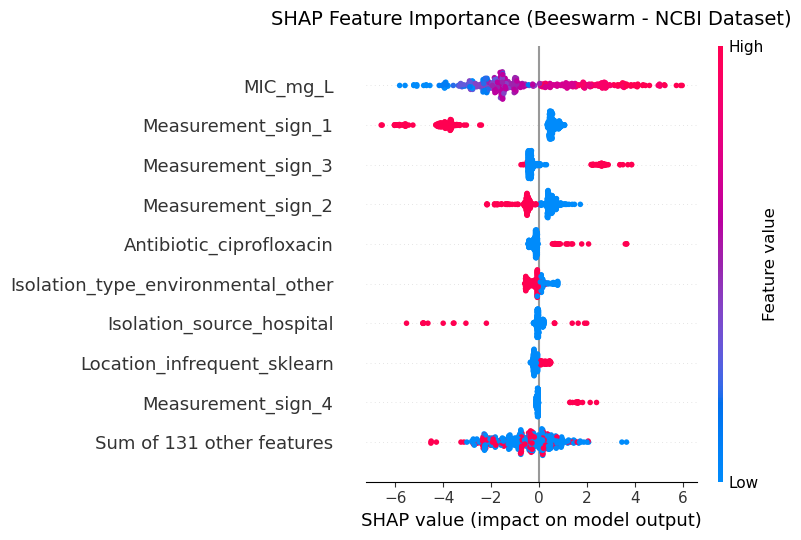

Global Summary Plot saved to ../reports\shap_summary.png


In [5]:
reports_dir = "../reports"
os.makedirs(reports_dir, exist_ok=True)

plt.figure(figsize=(10, 6))
shap.plots.beeswarm(shap_values, show=False)
plt.title("SHAP Feature Importance (Beeswarm - NCBI Dataset)", fontsize=14, pad=15)
plt.tight_layout()

summary_plot_path = os.path.join(reports_dir, "shap_summary.png")
plt.savefig(summary_plot_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Global Summary Plot saved to {summary_plot_path}")

## 5. Local Explanation: Waterfall Plots

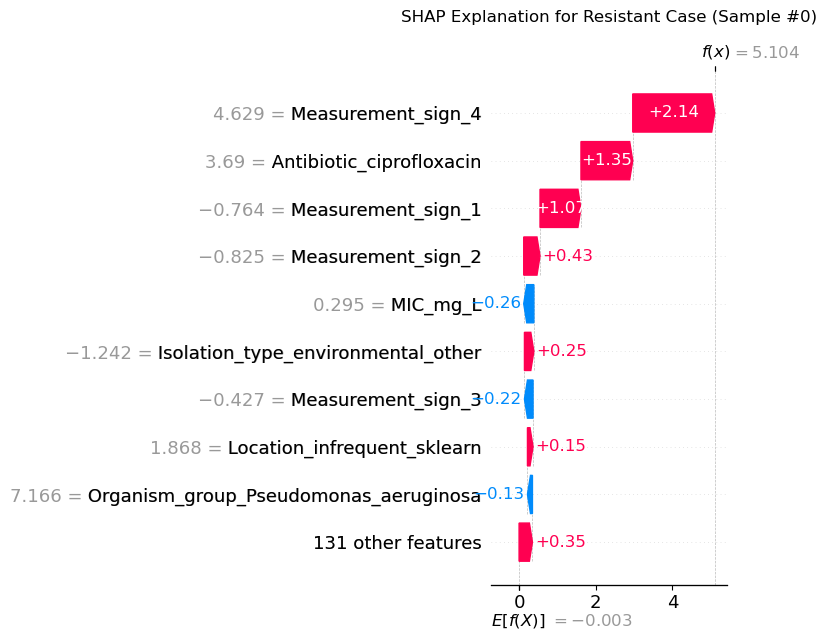

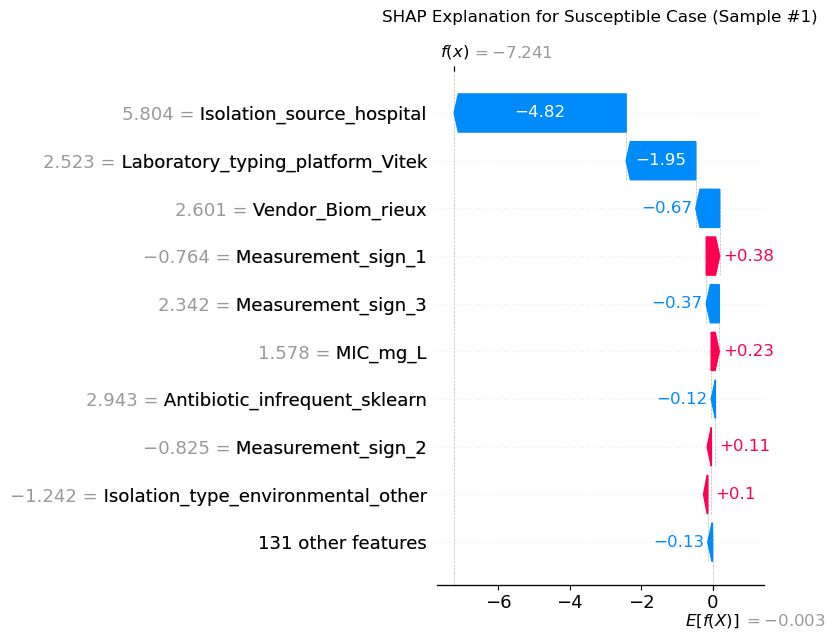

In [6]:
y_sample_pred = model.predict(X_sample)
resistant_idx = np.where(y_sample_pred == 1)[0]
susceptible_idx = np.where(y_sample_pred == 0)[0]

# Local Resistant Prediction Explanation
if len(resistant_idx) > 0:
    idx_res = resistant_idx[0]
    plt.figure(figsize=(8, 5))
    shap.plots.waterfall(shap_values[idx_res], show=False)
    plt.title(f"SHAP Explanation for Resistant Case (Sample #{idx_res})", fontsize=12, pad=15)
    plt.tight_layout()
    local_res_path = os.path.join(reports_dir, "shap_local_resistant.png")
    plt.savefig(local_res_path, dpi=300, bbox_inches='tight')
    plt.show()

# Local Susceptible Prediction Explanation
if len(susceptible_idx) > 0:
    idx_sus = susceptible_idx[0]
    plt.figure(figsize=(8, 5))
    shap.plots.waterfall(shap_values[idx_sus], show=False)
    plt.title(f"SHAP Explanation for Susceptible Case (Sample #{idx_sus})", fontsize=12, pad=15)
    plt.tight_layout()
    local_sus_path = os.path.join(reports_dir, "shap_local_susceptible.png")
    plt.savefig(local_sus_path, dpi=300, bbox_inches='tight')
    plt.show()